<a href="https://colab.research.google.com/github/askazera/Calculator/blob/master/Random-Forest-Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importacao e padronizacao

In [ ]:
# 1. IMPORTAÇÃO DAS BIBLIOTECAS
import pandas as pd
import spacy

# CARREGAMENTO DO MODELO DE LINGUAGEM SPACY (português)
nlp = spacy.load("pt_core_news_sm")

# LEITURA DA BASE DE DADOS
df = pd.read_excel('/content/rotulacao.xlsx')


# 4. AGRUPAMENTO DE CATEGORIAS SEMELHANTES (opcional)
agrupamento = {
    'cupom': 'benefícios_promocionais',
    'cashback': 'benefícios_promocionais',
    'pontos': 'benefícios_promocionais',
    'cadastro': 'suporte_cliente',
    'pos-venda': 'suporte_cliente',
    'garantia': 'suporte_cliente',
    'devolucao': 'logistica_pos_venda',
    'troca': 'logistica_pos_venda',
    'reembolso': 'logistica_pos_venda',
}
df['Categoria'] = df['Categoria'].replace(agrupamento)

In [ ]:
df

,Índice,Reclamação,Empresa,Categoria
0,1,Já faz 2 MESES que não a datas para envio ao F...,Mercado Livre,entrega
1,2,Motorola Enviou Uma Caixa Sem Celular [Editado...,Mercado Livre,produto
2,3,Descumprimento do prazo de entrega corriqueiro,Mercado Livre,entrega
3,4,ATRASO NA COMISSÃO AFILIADOS,Mercado Livre,entrega
4,5,Não recebi os produtos,Mercado Livre,entrega
...,...,...,...,...
1654,1720,Cancelamento de Geladeira Philco,Philco,cancelamento
1655,1721,Venda enganosa na Black Friday. Comprei um ven...,Philco,propaganda_enganosa
1656,1722,Compra concluída e cancelada uma semana depois,Philco,cancelamento
1657,1723,Cancelamento de pedido,Philco,cancelamento


##pré-processamento

In [ ]:
# Contagem absoluta e percentual das categorias
print("Distribuição de reclamações por categoria - base original:\n")
df_categoria = df['Categoria'].value_counts()
df_percentual = df['Categoria'].value_counts(normalize=True) * 100

# Cria um DataFrame com os resultados
df_distribuicao = pd.DataFrame({
    "Quantidade": df_categoria,
    "Percentual (%)": df_percentual.round(2)
})

print(df_distribuicao)


Distribuição de reclamações por categoria - base original:

                         Quantidade  Percentual (%)
Categoria                                          
entrega                         670           40.39
produto                         289           17.42
logistica_pos_venda             180           10.85
atendimento                     162            9.76
cancelamento                    148            8.92
propaganda_enganosa             103            6.21
pagamento                        38            2.29
benefícios_promocionais          36            2.17
suporte_cliente                  33            1.99


In [ ]:
# Filtrar categorias com pelo menos 100 amostras
categorias = df['Categoria'].value_counts()
categorias = categorias[categorias >= 100].index.tolist()

lista_balanceada = []

for cat in categorias:
    df_cat = df[df['Categoria'] == cat]
    # undersampling - escolhe 100 aleatórias (pois já garantimos que tem >= 100)
    df_cat_balanceado = df_cat.sample(100, random_state=42)
    lista_balanceada.append(df_cat_balanceado)

df_balanceado = pd.concat(lista_balanceada, ignore_index=True)

print("Quantidade por categoria após balanceamento para 100 amostras cada:")
print(df_balanceado['Categoria'].value_counts())

# Pré-processamento com spaCy
def preprocessar_spacy(texto):
    doc = nlp(texto.lower())
    return " ".join([
        token.lemma_
        for token in doc
        if token.is_alpha and not token.is_stop
    ])

df_balanceado['texto_limpo'] = df_balanceado['Reclamação'].astype(str).apply(preprocessar_spacy)

# Salvar CSV
df_balanceado.to_csv('df_balanceado.csv', index=False)
print("Pré-processamento finalizado e dados balanceados salvos em 'df_balanceado.csv'.")


Quantidade por categoria após balanceamento para 100 amostras cada:
Categoria
entrega                100
produto                100
logistica_pos_venda    100
atendimento            100
cancelamento           100
propaganda_enganosa    100
Name: count, dtype: int64
Pré-processamento finalizado e dados balanceados salvos em 'df_balanceado.csv'.


In [ ]:
df_balanceado

,Índice,Reclamação,Empresa,Categoria,texto_limpo
0,918,Alto atraso no recebimento de um pedido.,Kabum,entrega,alto atraso recebimento pedido
1,440,Produto não enviado e cancelado causando prejuízo,Amazon Brasil,entrega,produto enviar cancelar causando prejuízo
2,1216,Pedido #45307403 não entregue,Madeira Madeira,entrega,pedir entregar
3,1593,Atraso na entrega/ sem estoque,Philco,entrega,atraso estoque
4,719,Falha na entrega,Renner,entrega,falha entrega
...,...,...,...,...,...
595,1441,Black Friday ENGANOSA,Madeira Madeira,propaganda_enganosa,black friday enganoso
596,255,Não recebi,Amazon Brasil,propaganda_enganosa,recebi
597,1254,"Não confie nessa empresa, decepção garantida.",Madeira Madeira,propaganda_enganosa,confie empresa decepção garantido
598,1371,Anúncio enganoso,Madeira Madeira,propaganda_enganosa,anúncio enganoso


##treino e teste

In [ ]:
# IMPORTAÇÃO DAS BIBLIOTECAS
import pandas as pd
import spacy
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# CARREGAR O DATAFRAME BALANCEADO E PRÉ-PROCESSADO
df_balanceado = pd.read_csv('df_balanceado.csv')

# SEPARAÇÃO ENTRE TREINO E TESTE
X_train, X_test, y_train, y_test = train_test_split(
    df_balanceado['texto_limpo'],           # variáveis independentes (textos)
    df_balanceado['Categoria'],             # variável dependente (rótulos)
    test_size=0.2,                          # 20% dos dados para teste
    random_state=42,                        # garante reprodutibilidade
    stratify=df_balanceado['Categoria']    # mantém proporção de classes
)

print("\nContagem de categorias no conjunto de TREINO:")
print(y_train.value_counts())

print("\nContagem de categorias no conjunto de TESTE:")
print(y_test.value_counts())

# TRANSFORMAÇÃO DOS TEXTOS EM NÚMEROS (VETORIZAÇÃO)
vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=5000)  # considera palavras e pares de palavras
X_train_vec = vectorizer.fit_transform(X_train)  # ajusta e transforma os dados de treino
X_test_vec = vectorizer.transform(X_test)       # transforma os dados de teste

# RANDOM FOREST COM RANDOMIZED SEARCH

# Parâmetros para testar no RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300],         # número de árvores
    'max_depth': [10, 20, 30, None],         # profundidade máxima
    'min_samples_split': [2, 5, 10],         # mínimo de amostras para dividir nó
    'min_samples_leaf': [1, 2, 4],           # mínimo de amostras por folha
    'class_weight': ['balanced', None]       # balanceamento das classes
}

modelo_rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    modelo_rf,
    param_distributions=param_dist,   # parâmetros para testar
    n_iter=20,                       # número de combinações testadas
    cv=3,                            # validação cruzada com 3 folds
    verbose=2,
    n_jobs=-1,                       # usa todos os núcleos da CPU
    random_state=42
)

# Treinamento do modelo com busca dos melhores parâmetros
random_search.fit(X_train_vec, y_train)

# Melhor modelo encontrado
modelo_final = random_search.best_estimator_

# AVALIAÇÃO

# Faz previsões com os dados de teste
y_pred = modelo_final.predict(X_test_vec)




Contagem de categorias no conjunto de TREINO:
Categoria
atendimento            80
propaganda_enganosa    80
entrega                80
cancelamento           80
logistica_pos_venda    80
produto                80
Name: count, dtype: int64

Contagem de categorias no conjunto de TESTE:
Categoria
entrega                20
atendimento            20
logistica_pos_venda    20
produto                20
propaganda_enganosa    20
cancelamento           20
Name: count, dtype: int64
Fitting 3 folds for each of 20 candidates, totalling 60 fits


In [ ]:
# === AVALIAÇÃO DO MODELO ===

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import joblib

# === PREVISÕES ===
y_train_pred = modelo_final.predict(X_train_vec)
y_test_pred = modelo_final.predict(X_test_vec)

# === RELATÓRIOS SEPARADOS ===
print("\n===== RELATÓRIO TREINO =====")
print(classification_report(y_train, y_train_pred))

print("\n===== RELATÓRIO TESTE =====")
print(classification_report(y_test, y_test_pred))

# === TABELA COMPARATIVA ===
def gerar_metricas(y_real, y_pred):
    return {
        "Accuracy": accuracy_score(y_real, y_pred),
        "Precision": precision_score(y_real, y_pred, average="weighted"),
        "Recall": recall_score(y_real, y_pred, average="weighted"),
        "F1-Score": f1_score(y_real, y_pred, average="weighted")
    }

metricas = pd.DataFrame({
    "Treino": gerar_metricas(y_train, y_train_pred),
    "Teste": gerar_metricas(y_test, y_test_pred)
})

# Transpõe para ficar mais legível
metricas = metricas.T.round(3)

print("\n===== MÉTRICAS CONSOLIDADAS =====")
print(metricas)

# === MATRIZ DE CONFUSÃO - FUNÇÃO ===
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    labels = np.unique(y_true)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Previsto", fontsize=12)
    plt.ylabel("Real", fontsize=12)
    plt.tight_layout()
    plt.show()


# === SALVAR MODELO E VETORIZADOR ===
joblib.dump(modelo_final, "modelo_random_forest.pkl")
joblib.dump(vectorizer, "vetorizador_tfidf.pkl")



===== RELATÓRIO TREINO =====
                     precision    recall  f1-score   support

        atendimento       0.84      0.86      0.85        80
       cancelamento       0.91      0.89      0.90        80
            entrega       0.89      0.80      0.84        80
logistica_pos_venda       0.91      0.88      0.89        80
            produto       0.76      0.82      0.79        80
propaganda_enganosa       0.76      0.80      0.78        80

           accuracy                           0.84       480
          macro avg       0.85      0.84      0.84       480
       weighted avg       0.85      0.84      0.84       480


===== RELATÓRIO TESTE =====
                     precision    recall  f1-score   support

        atendimento       0.78      0.70      0.74        20
       cancelamento       0.79      0.95      0.86        20
            entrega       0.86      0.60      0.71        20
logistica_pos_venda       0.82      0.70      0.76        20
            produto   

['vetorizador_tfidf.pkl']

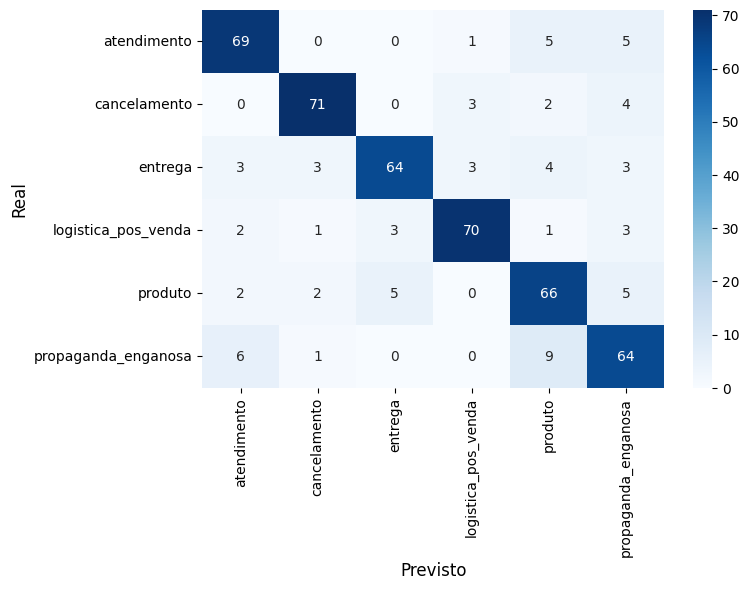

In [ ]:
# === MATRIZ DE CONFUSÃO PARA TREINO ===
plot_confusion_matrix(y_train, y_train_pred, "Treino")

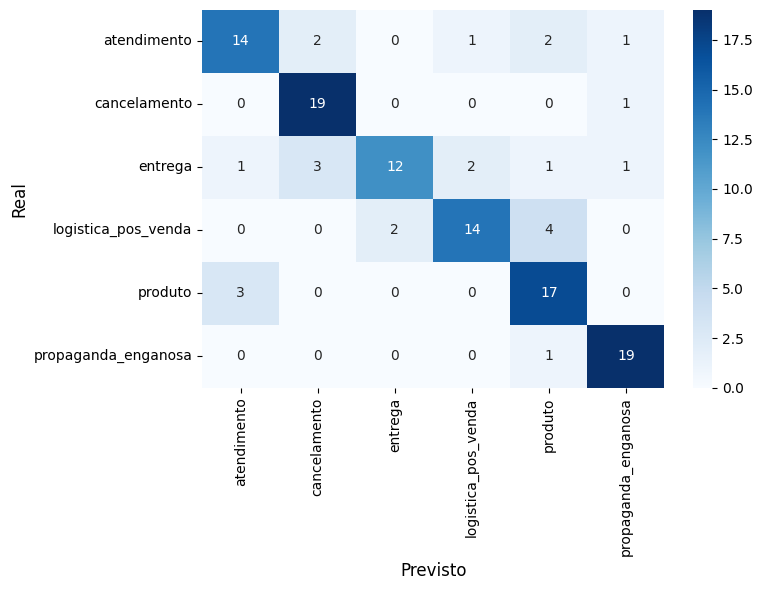

In [ ]:
# === MATRIZ DE CONFUSÃO PARA TESTE ===
plot_confusion_matrix(y_test, y_test_pred, "Teste")

In [ ]:
!pip install shap


#resultados e construção de pipeline

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import FunctionTransformer
import joblib
import spacy

# Carrega o modelo spaCy
nlp = spacy.load('pt_core_news_sm')  # ou outro modelo em português que você tenha

# Função de pré-processamento com spaCy (lematização + remoção stopwords)
def preprocessar_spacy(textos):
    resultados = []
    for texto in textos:
        doc = nlp(texto.lower())
        lemmas = [token.lemma_ for token in doc if token.is_alpha and not token.is_stop]
        resultados.append(" ".join(lemmas))
    return resultados

X_train_raw = df_balanceado['Reclamação']
y_train = df_balanceado['Categoria']

# Cria pipeline com spaCy como pré-processamento
pipeline = Pipeline([
    ("preprocessamento", FunctionTransformer(preprocessar_spacy)),
    ("vetorizador", TfidfVectorizer(ngram_range=(1, 2), max_features=5000)),
    ("modelo", RandomForestClassifier(random_state=42))
])

pipeline.fit(X_train_raw, y_train)

joblib.dump(pipeline, 'pipeline_completo_spacy.pkl')

print("Pipeline completo com spaCy salvo com sucesso!")


Pipeline completo com spaCy salvo com sucesso!


#inferencia

In [ ]:
# Carrega o pipeline completo previamente salvo, que já inclui pré-processamento, vetorização e modelo treinado
pipeline = joblib.load('pipeline_completo_spacy.pkl')

# Lista de novos textos (reclamações) para classificar
novos_textos = [
    "Meu pedido não chegou",
    "Celular chegou quebrado",
    "Gostaria de devolver o produto"
]

# Aplica o pipeline nos novos textos para prever as categorias
categorias = pipeline.predict(novos_textos)

# Exibe cada texto com a categoria prevista correspondente
for texto, categoria in zip(novos_textos, categorias):
    print(f"Reclamação: {texto}")
    print(f"→ Categoria prevista: {categoria}\n")

Reclamação: Meu pedido não chegou
→ Categoria prevista: entrega

Reclamação: Celular chegou quebrado
→ Categoria prevista: produto

Reclamação: Gostaria de devolver o produto
→ Categoria prevista: logistica_pos_venda



## outras análises

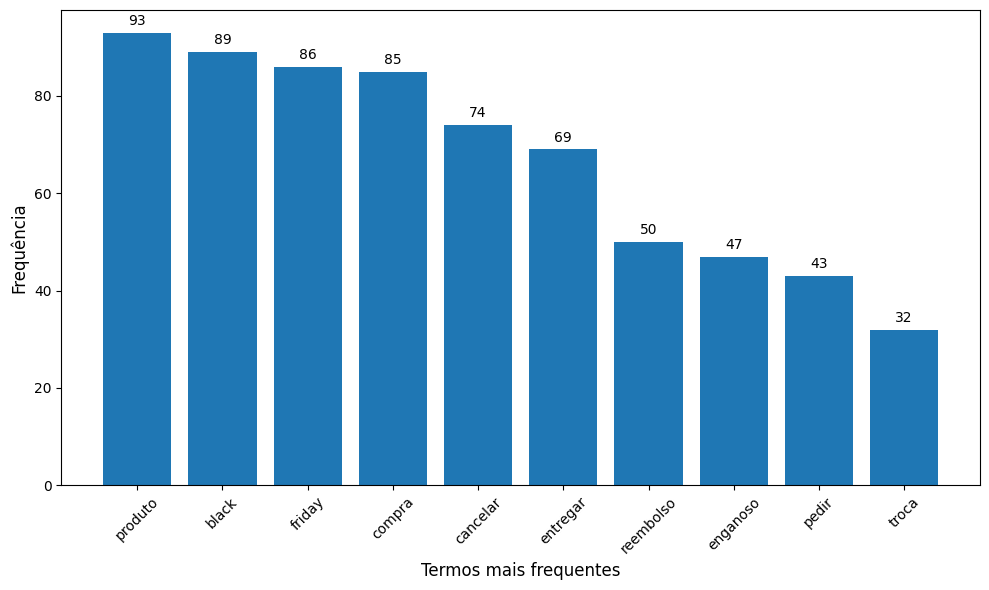

In [ ]:
import matplotlib.pyplot as plt

# Seleciona os 10 termos mais frequentes
df_top10 = df_freq.sort_values(by="frequencia", ascending=False).head(10)

# Cria o gráfico de barras
plt.figure(figsize=(10, 6))
barras = plt.bar(df_top10["termo"], df_top10["frequencia"])
plt.xlabel("Termos mais frequentes", fontsize=12)
plt.ylabel("Frequência", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

# Adiciona rótulos de frequência no topo de cada barra
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, altura + 1, str(int(altura)),
             ha='center', va='bottom', fontsize=10)

plt.show()
